# Notebook overview

**Goal.** This notebook shows how to run an open‑source chat LLM in Google Colab to solve four mini‑tasks around **homebrewing**:
1) guided **paraphrasing/style transfer**, 2) **recipe & process** prompting, 3) a **multi‑turn chat playground**, and 4) **sentiment classification by prompting** (zero‑shot vs few‑shot).

**What you’ll do (step‑by‑step)**
1. **Install dependencies** (`transformers`, `accelerate`, etc.).  
2. **Auto‑load a small chat model** depending on GPU/CPU availability.  
3. Implement a **`generate_chat`** helper (with a safe clamp for `temperature=0`).  
4. Use the **Prompting Playground** to craft `system/user` prompts and tweak decoding (`temperature`, `top_p`, `do_sample`).  
5. **Task A – Paraphrasing/Style:** rewrite in Spanish with **tone** and **target length** control (no fabrications).  
6. **Task B – Sentiment by prompting (beer):** compare **zero‑shot** vs **few‑shot** on a tiny synthetic set.  
7. **Decoding experiment:** vary `temperature`/`top_p` and discuss **diversity vs coherence**.  
8. **BJCP mini‑table:** inspect typical ranges and auto‑generate **recipe/process** prompts.


# Practice: **Generative Model in Colab**

**Objective:** Use an open‑source chat LLM in Colab Free to (1) perform *paraphrasing/style transfer*, (2) guide *recipe/process planning* for homebrewing, (3) run a small *multi‑turn chat* playground, and (4) do *sentiment classification via prompting* (zero‑shot vs few‑shot) with simple metrics.

**What you will do**
1. Load an open chat model with `transformers`.
2. Generate **paraphrases/style** in Spanish with tone and target‑length control (theme: **homebrewing beer**).
3. Do **sentiment classification** (pos/neg/neu) via prompting on beer reviews; compare *zero‑shot* vs *few‑shot*.
4. Practice **prompting** in a *Playground* and a **multi‑turn conversation** with persistent history.
5. Explore a **minimal BJCP table** (IPA, Oatmeal Stout, German Pils) and generate recipe/process prompts.

**Notes**
...
- `chat_turn(user_text, ...)` → Adds the user turn, **generates** the answer and stores it in history.

**Tips:**
- If you set `temperature=0.0`, use `do_sample=False` for greedy decoding.
- Turn on `show_history=True` to print a compact summary of the history.


## 1) Library installation
Run this cell once. If there is no GPU, it will work on CPU (slower).

In [1]:
%%bash
pip -q install --upgrade transformers accelerate sentencepiece
# bitsandbytes enables 4-bit on GPU. If it fails on CPU, there is a non-4-bit route below.
pip -q install bitsandbytes scikit-learn matplotlib pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.8/375.8 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 MB 33.0 MB/s eta 0:00:00


## 2) Model loading (auto‑selection)
The cell detects whether a GPU is available and picks a suitable model automatically:
- **With GPU**: it tries `Qwen/Qwen2.5-1.5B-Instruct` in 4‑bit; if it fails, it falls back to `TinyLlama/TinyLlama-1.1B-Chat-v1.0`.
- **Without GPU (CPU)**: it uses `TinyLlama/TinyLlama-1.1B-Chat-v1.0`.

In [2]:
import torch, os, gc
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

PREFERRED_GPU_MODEL = 'Qwen/Qwen2.5-1.5B-Instruct'
FALLBACK_MODEL = 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'

def safe_load(model_name, fourbit=False):
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    kwargs = {}
    if fourbit:
        try:
            bnb = BitsAndBytesConfig(load_in_4bit=True,
                                     bnb_4bit_quant_type='nf4',
                                     bnb_4bit_compute_dtype=torch.float16)
            kwargs.update(dict(quantization_config=bnb, device_map='auto', torch_dtype=torch.float16))
        except Exception as e:
            print('bitsandbytes no disponible, cargando sin 4-bit:', e)
    else:
        if DEVICE == 'cuda':
            kwargs.update(dict(device_map='auto', torch_dtype=torch.float16))
        else:
            kwargs.update(dict(device_map={'': 'cpu'}, torch_dtype=torch.float32))
    model = AutoModelForCausalLM.from_pretrained(model_name, **kwargs)
    model.eval()
    return tokenizer, model

try:
    if DEVICE == 'cuda':
        print('Intentando cargar en 4-bit:', PREFERRED_GPU_MODEL)
        tokenizer, model = safe_load(PREFERRED_GPU_MODEL, fourbit=True)
        SELECTED = PREFERRED_GPU_MODEL
    else:
        print('Cargando en CPU:', FALLBACK_MODEL)
        tokenizer, model = safe_load(FALLBACK_MODEL, fourbit=False)
        SELECTED = FALLBACK_MODEL
except Exception as e:
    print('Fallo carga preferida:', e)
    print('Cargando modelo de respaldo en CPU:', FALLBACK_MODEL)
    if DEVICE=='cuda': torch.cuda.empty_cache()
    gc.collect()
    tokenizer, model = safe_load(FALLBACK_MODEL, fourbit=False)
    SELECTED = FALLBACK_MODEL

print('Modelo seleccionado =>', SELECTED)
EOS = tokenizer.eos_token_id if tokenizer.eos_token_id is not None else tokenizer.convert_tokens_to_ids('</s>')

Device: cuda
Intentando cargar en 4-bit: Qwen/Qwen2.5-1.5B-Instruct


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Modelo seleccionado => Qwen/Qwen2.5-1.5B-Instruct


## 3) Chat function and helpers
Implements `generate_chat` using the tokenizer's chat template. Add a small **temperature clamp** to avoid errors when `temperature=0`.
...

In [3]:
def generate_chat(messages, temperature=0.2, top_p=0.95, max_new_tokens=256, do_sample=True):
    """messages = [{"role": "system|user|assistant", "content": str}, ...]"""
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    # 🔧 Patch: if sampling is requested with temperature <= 0, switch to greedy
    if do_sample and float(temperature) <= 0.0:
        do_sample = False
    # In greedy, temperature is not used; set a safe value to avoid internal validations
    if not do_sample and (temperature is None or float(temperature) <= 0.0):
        temperature = 1.0
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            do_sample=do_sample,
            temperature=float(temperature),
            top_p=float(top_p),
            max_new_tokens=int(max_new_tokens),
            eos_token_id=EOS,
            pad_token_id=EOS
        )
    gen = output_ids[0][inputs['input_ids'].shape[1]:]
    text = tokenizer.decode(gen, skip_special_tokens=True)
    return text.strip()

# Smoke test: greedy (do_sample=False)
test = generate_chat([
    {"role": "system", "content": "Eres un asistente útil y conciso."},
    {"role": "user", "content": "Di solo: ok."}
], temperature=0.0, top_p=1.0, max_new_tokens=5, do_sample=False)
print('Respuesta de prueba =>', repr(test))

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Respuesta de prueba => 'Ok.'


## Prompting playground
Write your own `system/user` structured prompts and adjust `temperature`, `top_p`, and `do_sample`.
Suggestions:
- For **greedy** use `do_sample=False` (temperature is ignored in that case).
- Keep clear instructions in `system` (e.g., *"responde en español, no inventes"*).

In [4]:
# 👇 Edit your messages and parameters here
messages = [
    {"role": "system", "content": "Eres un experto en elaboración de cerveza casera. Responde en español, con precisión y sin inventar."},
    {"role": "user",   "content": "¿Qué diferencia hay entre una IPA americana y una German Pils en aroma y amargor?"}
]

temperature = 0.2   # diversidad (si do_sample=True)
top_p = 0.5       # nucleus sampling
do_sample = True    # pon False para greedy
max_new_tokens = 160

respuesta = generate_chat(messages,
                          temperature=temperature,
                          top_p=top_p,
                          max_new_tokens=max_new_tokens,
                          do_sample=do_sample)
print(respuesta)

La diferencia entre una IPA (American Pale Ale) y una German Pilsner (Pilzner) radica principalmente en su origen, estilo de fermentación y la cantidad de malta utilizada.

1. Aroma: Las IPAs son conocidas por sus aromas más intensos, que pueden incluir notas de café, chocolate, especias como canela o menta, además de toques de vainilla. En contraste, las Pilsners tienen un aroma más agradable, típicamente ligero y fresco, con notas de hielo, sal y leche.

2. Amargo: Las IPAs suelen ser más ácidas debido a su fermentación aleatoria, lo que los hace más ácidos y menos dulces.


## 4) Task A — Paraphrasing / Style (generation)
Controlled rewriting by **tone** and **target length** (without inventing facts).

In [5]:
texto_es = (
    "Para elaborar una IPA casera, mantén el macerado a 66–67 °C durante 60 minutos, "
    "hierve 60 minutos, añade lúpulo en adiciones tardías y realiza dry hop en fermentación. "
    "Controla la temperatura de fermentación según la levadura ale (18–20 °C) y asegúrate de una buena sanitización."
)

def restyle(texto, tono="docente, claro y preciso", longitud="120-160 palabras",
            temperature=0.4, top_p=0.95, max_new_tokens=180, do_sample=True):
    sys = {"role": "system", "content": "Eres un asistente que reescribe en español sin añadir datos nuevos."}
    user = {"role": "user", "content": (
        f"Reescribe el siguiente texto con tono: {tono}.\n"
        f"Longitud objetivo: {longitud}.\n"
        f"Mantén el significado y no inventes hechos.\n\nTexto:\n{texto}"
    )}
    return generate_chat([sys, user], temperature=temperature, top_p=top_p,
                         max_new_tokens=max_new_tokens, do_sample=do_sample)

print('--- Original ---')
print(texto_es)
print('\n--- Reescritura (T=0.4) ---')
print(restyle(texto_es, temperature=0.4))
print('\n--- Reescritura (T=0.8) ---')
print(restyle(texto_es, temperature=0.8))

--- Original ---
Para elaborar una IPA casera, mantén el macerado a 66–67 °C durante 60 minutos, hierve 60 minutos, añade lúpulo en adiciones tardías y realiza dry hop en fermentación. Controla la temperatura de fermentación según la levadura ale (18–20 °C) y asegúrate de una buena sanitización.

--- Reescritura (T=0.4) ---
La elaboración de una IPA casera se inicia con la maceración al 66-67°C durante 60 minutos. Posteriormente, debe hervir por 60 minutos antes de incorporar lúpulo en adicionales tardías para su fermentación. La temperatura de fermentación debe ser controlada según la levadura local (18-20°C), manteniendo un buen estado sanitario del proceso.

--- Reescritura (T=0.8) ---
Elaborar una IPA casera requiere un proceso cuidadoso. Mantén la cerveza a 66-67 grados centígrados durante 60 minutos bajo el macerado. Añade lúpulo en dos pasos para mayor control. Hervir la cerveza por 60 minutos después del macerado. Realiza dry-hop durante la fermentación para añadir olores. Cont

## 5) Task B — Sentiment Classification via prompting (beer)
We will evaluate *zero‑shot* and *few‑shot* over a small **synthetic** dataset (60 instances: pos/neg/neu).


== Resultados ZERO ==
              precision    recall  f1-score   support

         neg      1.000     0.833     0.909        12
         neu      0.857     1.000     0.923        12
         pos      1.000     1.000     1.000        12

    accuracy                          0.944        36
   macro avg      0.952     0.944     0.944        36
weighted avg      0.952     0.944     0.944        36

Matriz de confusión (pos/neg/neu):
 [[12  0  0]
 [ 0 10  2]
 [ 0  0 12]]


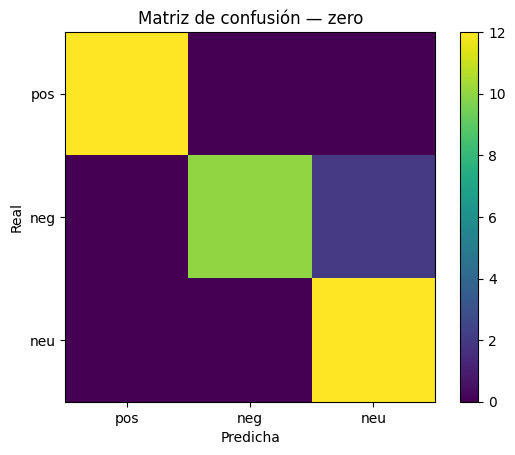


== Resultados FEW ==
              precision    recall  f1-score   support

         neg      0.857     1.000     0.923        12
         neu      1.000     0.667     0.800        12
         pos      0.857     1.000     0.923        12

    accuracy                          0.889        36
   macro avg      0.905     0.889     0.882        36
weighted avg      0.905     0.889     0.882        36

Matriz de confusión (pos/neg/neu):
 [[12  0  0]
 [ 0 12  0]
 [ 2  2  8]]


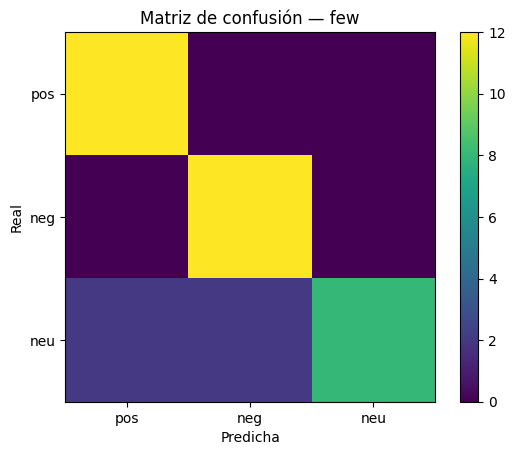

In [6]:
import random
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

random.seed(42)

positivas = [
  "Aroma cítrico intenso y espuma persistente.",
  "Fermentación limpia, sin off-flavors.",
  "Buen amargor y final seco, muy bebible.",
  "Carbonatación justa y color dorado brillante.",
  "Dry hop muy expresivo, excelente NEIPA.",
  "Atenuación perfecta, densidad final en rango."
]
negativas = [
  "Sabor a cartón húmedo (oxidación) evidente.",
  "Fenoles medicinales, probablemente contaminación.",
  "Diacetilo notable, a mantequilla.",
  "Subcarbonatada y turbia sin intención.",
  "Amargor áspero y desequilibrado.",
  "Aromas sulfurosos, levadura estresada."
]
neutras = [
  "Maceré a 66 °C durante una hora.",
  "La densidad original fue 1.060.",
  "Añadí 50 g de lúpulo en dry hop.",
  "Fermenté 10 días a 19 °C.",
  "Usé levadura US-05 en sobre.",
  "Carbonaté a 2.2 volúmenes de CO₂."
]

data = [(t,'pos') for t in positivas] + [(t,'neg') for t in negativas] + [(t,'neu') for t in neutras]
data = data*2  # 60 instancias (20 por clase)
random.shuffle(data)

def classify_sentiment(text, mode='zero'):
    sys = {"role": "system", "content": "Eres un clasificador de sentimiento en español. Devuelve solo: pos, neg o neu."}
    if mode=='few':
        few = (
            'Texto: "Aroma fresco, fermentación limpia y final seco."\nEtiqueta: pos\n'
            'Texto: "Correcta para una primera cocción casera."\nEtiqueta: neu\n'
            'Texto: "Presenta sabores a mantequilla y solvente."\nEtiqueta: neg\n'
        )
        user = {"role": "user", "content": few + f'Texto: "{text}"\nEtiqueta:'}
    else:
        user = {"role": "user", "content": f'Clasifica el sentimiento como pos, neg o neu.\nTexto: "{text}"\nEtiqueta:'}
    out = generate_chat([sys, user], temperature=0.0, top_p=1.0, max_new_tokens=5, do_sample=False).lower()
    if 'pos' in out: return 'pos'
    if 'neg' in out: return 'neg'
    if 'neu' in out or 'neut' in out: return 'neu'
    return 'neu'

def run_eval(mode='zero'):
    y_true, y_pred = [], []
    for text, lab in data:
        y_true.append(lab)
        y_pred.append(classify_sentiment(text, mode=mode))
    print('\n== Resultados', mode.upper(), '==')
    print(classification_report(y_true, y_pred, digits=3))
    cm = confusion_matrix(y_true, y_pred, labels=['pos','neg','neu'])
    print('Matriz de confusión (pos/neg/neu):\n', cm)
    plt.figure()
    plt.imshow(cm, interpolation='nearest')
    plt.title(f'Matriz de confusión — {mode}')
    plt.colorbar()
    ticks = ['pos','neg','neu']
    plt.xticks(range(3), ticks)
    plt.yticks(range(3), ticks)
    plt.xlabel('Predicha')
    plt.ylabel('Real')
    plt.show()
    return cm

# Run both evaluations:
cm_zero = run_eval('zero')
cm_few  = run_eval('few')

## 6) Decoding experiment (impact of *temperature* and *top_p*)
Generate paraphrases while varying `temperature`/`top_p` and discuss differences in **diversity** and **coherence**.

**Important:** when `temperature=0.0`, we force **greedy** (`do_sample=False`) to avoid a validation error.

In [7]:
settings = [
    (0.0, 1.0),
    (0.2, 0.95),
    (0.8, 0.90),
]
for t, p in settings:
    print(f"\n### temperature={t}, top_p={p}")
    out = restyle(texto_es, temperature=t, top_p=p, do_sample=(t>0.0))
    print(out)



### temperature=0.0, top_p=1.0
Para preparar una IPA casera, sigue estos pasos:

1. Macéstralo a 66-67°C durante 60 minutos.
2. Luego, hierva por 60 minutos.
3. Añada lúpulo en adicionales tardías.
4. Realiza dry hopping durante la fermentación.
5. Mantén la temperatura de fermentación entre 18-20°C según la levadura local.
6. Asegúrate de una buena limpieza antes de comenzar.

### temperature=0.2, top_p=0.95
Para preparar una IPA casera, sigue estos pasos:

1. Debe ser macerada a 66-67°C durante 60 minutos.
2. Luego debe hervir durante 60 minutos.
3. Añadir lúpulo en adicionales tardías.
4. Realizar dry hop durante la fermentación.
5. Controlar la temperatura de fermentación según la levadura local (18-20°C).
6. Mantener la buena higiene durante todo el proceso.

### temperature=0.8, top_p=0.9
La elaboración de una IPA casera requiere mantener los siguientes pasos:

1. **Maceración**: La cerveza debe estar almacendada a 66-67°C durante 60 minutos. Posteriormente, es necesario llevarl

## **Multi‑turn Conversation** Playground

Use a persistent history of `system/user/assistant` messages.

**Functions:**
- `reset_chat(system=...)` → Initializes history with a system prompt.
- `chat_turn(user_text, ...)` → Adds the user turn, **generates** the response, and stores it.

**Tips:**
- If you set `temperature=0.0`, use `do_sample=False` for greedy decoding.
- Turn on `show_history=True` to print a compact summary of the history.

In [8]:
# Multi-turn conversation helpers
CHAT_HISTORY = []

def reset_chat(system="Eres maestro cervecero. Responde en español con pasos claros y consejos de seguridad alimentaria."):
    """Reinicia el historial con un system prompt."""
    global CHAT_HISTORY
    CHAT_HISTORY = [{"role": "system", "content": system}]
    print("[OK] Historial reiniciado.")

def chat_turn(user_text,
             temperature=0.2,
             top_p=0.95,
             max_new_tokens=256,
             do_sample=True,
             show_history=False):
    """Añade turno de usuario, genera respuesta y la guarda. Devuelve el texto de la respuesta."""
    global CHAT_HISTORY
    if not CHAT_HISTORY or CHAT_HISTORY[0].get("role") != "system":
        reset_chat()
    CHAT_HISTORY.append({"role": "user", "content": user_text})
    reply = generate_chat(CHAT_HISTORY,
                          temperature=temperature,
                          top_p=top_p,
                          max_new_tokens=max_new_tokens,
                          do_sample=do_sample)
    CHAT_HISTORY.append({"role": "assistant", "content": reply})
    print(reply)
    if show_history:
        print("\n--- Historial (sin system) ---")
        for m in CHAT_HISTORY:
            if m["role"] != "system":
                who = "U>" if m["role"] == "user" else "A>"
                print(f"{who} {m['content'][:400]}")
    return reply

# Example usage:
reset_chat()
_ = chat_turn("Quiero hacer una IPA casera de 20 litros: ¿qué perfil de macerado y lúpulos recomiendas?", temperature=0.3, do_sample=True)
_ = chat_turn("¿Cómo controlo la fermentación y evito off-flavors como diacetilo u oxidación?", temperature=0.3, do_sample=True)
_ = chat_turn("¿Sabes cómo preparar una hamburguesa?", temperature=0.3, do_sample=True)

[OK] Historial reiniciado.
Para preparar una IPA (India Pale Ale) de 20 litros, es importante elegir un perfil de macerado adecuado para lograr el equilibrio que caracteriza a esta variedad. Aquí te dejo algunos tips:

1. **Perfil de Macerado**: Un perfil de macerado típico para una IPA sería:
   - Lúpulo Citra: 5%
   - Amarillo Washington: 4%
   - Centennial: 3%

   Este perfil proporciona la amargor necesario, la acidez necesaria y el color rojizo característico de las IPAs.

2. **Lúpulos**: Los lúpulos son los ácidos más importantes en la fermentación. En este caso, puedes considerar:
   - Lúpulo Citra: 5% o 6%
   - Lúpulo Amarillo: 4% o 5%
   - Lúpulo Centennial: 3% o 4%

   Añade estos lúpulos durante la fermentación para asegurar la producción de los ácidos cetonas necesarios.

3. **Macerado**: El macerado
Controlar la fermentación y prevenir ofensivos flavors como diacetilo (diacetyldialcano) o la oxidación es crucial para mantener la calidad del vino. Aquí tienes algunas recome

## Minimal **BJCP** style table + *prompt* templates

This section adds a **mini BJCP** table with typical ranges and two helpers:
- `mostrar_bjcp()` → prints the table.
- `style_prompt(estilo, ...)` → produces ready‑to‑use prompts for the model (recipe, process and quality control).

**Note:** Ranges are indicative and simplified for teaching purposes.

In [9]:
import pandas as pd

BJCP_MINI = pd.DataFrame([
    {
        'Estilo': 'American IPA', 'BJCP': '21A',
        'OG': '1.056–1.070', 'FG': '1.008–1.014', 'ABV': '5.5–7.5%', 'IBU': '40–70', 'SRM': '6–14',
        'Levadura': 'US-05 / WLP001 (Chico)', 'Lúpulos': 'Citra, Simcoe, Cascade',
        'Notas': 'Aromas cítricos/resinosos; amargor firme; final relativamente seco.'
    },
    {
        'Estilo': 'Oatmeal Stout', 'BJCP': '16B',
        'OG': '1.045–1.065', 'FG': '1.010–1.018', 'ABV': '4.2–5.9%', 'IBU': '25–40', 'SRM': '22–40',
        'Levadura': 'S-04 / Wyeast 1084 (Irish Ale)', 'Lúpulos': 'East Kent Goldings, Fuggles',
        'Notas': 'Cuerpo cremoso, avena; tostados/chocolate; amargor moderado.'
    },
    {
        'Estilo': 'German Pils', 'BJCP': '5D',
        'OG': '1.044–1.050', 'FG': '1.008–1.013', 'ABV': '4.4–5.2%', 'IBU': '22–40', 'SRM': '2–5',
        'Levadura': 'W-34/70 / WLP830 (German Lager)', 'Lúpulos': 'Hallertau, Tettnang, Saaz',
        'Notas': 'Amargor limpio y definido; final seco; alta atenuación; lagering frío.'
    }
])

def mostrar_bjcp():
    display(BJCP_MINI)

def style_prompt(estilo,
                 volumen_l=20,
                 macerado="66–67 °C 60 min",
                 hervido="60 min",
                 objetivo_abv=None,
                 objetivo_ibu=None,
                 dry_hop=True,
                 restricciones="No inventes datos; prioriza sanitización y evita off-flavors (oxidación, diacetilo).",
                 salida="pasos + lista de ingredientes en gramos, cronograma de lúpulos y control de fermentación"):
    """Devuelve (messages, info_estilo) para pasar a generate_chat()."""
    row = BJCP_MINI[BJCP_MINI['Estilo'].str.lower()==estilo.strip().lower()]
    if row.empty:
        raise ValueError(f"Estilo no encontrado: {estilo} (usa: {', '.join(BJCP_MINI['Estilo'])})")
    info = row.iloc[0].to_dict()
    sys = {"role": "system", "content": (
        "Eres maestro cervecero. Responde en español con receta y proceso claros,"
        " respetando rangos BJCP del estilo. " + restricciones
    )}
    detalles = [
        f"Estilo: {info['Estilo']} (BJCP {info['BJCP']})",
        f"Volumen: {volumen_l} L",
        f"Rangos — OG: {info['OG']}, FG: {info['FG']}, ABV: {info['ABV']}, IBU: {info['IBU']}, SRM: {info['SRM']}",
        f"Levadura sugerida: {info['Levadura']}",
        f"Lúpulos sugeridos: {info['Lúpulos']}",
        f"Macerado objetivo: {macerado}",
        f"Hervido: {hervido}",
        f"Dry hop: {'sí' if dry_hop else 'no'}",
    ]
    if objetivo_abv: detalles.append(f"ABV objetivo: {objetivo_abv}")
    if objetivo_ibu: detalles.append(f"IBU objetivo: {objetivo_ibu}")
    prompt = (
        "Quiero una receta y proceso para el estilo indicado, con: " + ", ".join(detalles) + ".\n"
        "Incluye: " + salida + ".\n"
        "Indica controles de temperatura/oxígeno, pitch de levadura y, si aplica, lagering/diacetilo rest."
    )
    user = {"role": "user", "content": prompt}
    return [sys, user], info

# Example usage with the loaded model:
mostrar_bjcp()
msgs, info = style_prompt('American IPA', volumen_l=20, objetivo_abv='6.5%', objetivo_ibu='55–60', dry_hop=True)
print("\n--- Prompt generado (resumen) ---")
print(msgs[1]['content'][:300] + '...')
print("\n--- Respuesta del modelo (extracto) ---")
print(generate_chat(msgs, temperature=0.3, top_p=0.95, max_new_tokens=400)[:600])


,Estilo,BJCP,OG,FG,ABV,IBU,SRM,Levadura,Lúpulos,Notas
0,American IPA,21A,1.056–1.070,1.008–1.014,5.5–7.5%,40–70,6–14,US-05 / WLP001 (Chico),"Citra, Simcoe, Cascade",Aromas cítricos/resinosos; amargor firme; fina...
1,Oatmeal Stout,16B,1.045–1.065,1.010–1.018,4.2–5.9%,25–40,22–40,S-04 / Wyeast 1084 (Irish Ale),"East Kent Goldings, Fuggles","Cuerpo cremoso, avena; tostados/chocolate; ama..."
2,German Pils,5D,1.044–1.050,1.008–1.013,4.4–5.2%,22–40,2–5,W-34/70 / WLP830 (German Lager),"Hallertau, Tettnang, Saaz",Amargor limpio y definido; final seco; alta at...



--- Prompt generado (resumen) ---
Quiero una receta y proceso para el estilo indicado, con: Estilo: American IPA (BJCP 21A), Volumen: 20 L, Rangos — OG: 1.056–1.070, FG: 1.008–1.014, ABV: 5.5–7.5%, IBU: 40–70, SRM: 6–14, Levadura sugerida: US-05 / WLP001 (Chico), Lúpulos sugeridos: Citra, Simcoe, Cascade, Macerado objetivo: 66–67 °C...

--- Respuesta del modelo (extracto) ---
Receta y Proceso:

**Ingredientes:**

- **Hefe**: 3 kg
- **Lúpulo**: 1 kg
- **Macérato**: 1 kg

**Listado de Ingredientes en Gramos:**
- Hefe: 3000 g
- Lúpulo: 1000 g
- Macérato: 1000 g

**Proceso:**

1. **Preparación del Hefe:** 
   - Calentar la cerveza a 66°C durante 60 minutos.

2. **Fermentación:**
   - Enfriar la cerveza a 6°C durante 60 minutos.

3. **Desmaceración:**
   - Desmacer la cerveza a 20°C durante 60 minutos.

4. **Control de Temperatura y Oxigeno:**
   - Mantener la temperatura entre 20°C y 22°C durante todo el proceso.
   - Controlar el oxigeno para evitar oxidación.

5. **P
